# Исследование влияния частоты кадров (FPS) на точность классификации болезни Паркинсона

## Актуальность

Веб-сервис для скрининга болезни Паркинсона работает при частоте передачи видеопотока **20 FPS**. Исходные видеозаписи пациентов сделаны при 60 FPS. Вопрос: не приводит ли снижение частоты кадров к деградации качества классификатора?

## Цель

Оценить зависимость ROC-AUC классификаторов PD/HC от частоты кадров в диапазоне **5–60 FPS** и обосновать выбор 20 FPS для веб-сервиса.

## Методология

Исходные видео записаны при **60 FPS**. Для симуляции пониженной частоты кадров применяется прореживание временного ряда: из покадрового ряда нормированных расстояний, полученного через MediaPipe FaceMesh, выбирается каждый K-й кадр (`iloc[::K]`, где `K = 60 / FPS`). После прореживания для каждого значения FPS **заново вычисляются** все статистики — геометрические, скоростные и угловые. Такой подход точно воспроизводит, что увидел бы алгоритм при съёмке с заданной частотой.

```
Видео 60 FPS → MediaPipe FaceMesh → покадровый ряд расстояний (eye-norm)
    ↓  iloc[::K]
Прореженный ряд [FPS] → Savitzky-Golay(5,2) → vel / acc → статистики
    ↓
Датасет data_fps{FPS}.csv  (143 наблюдения: 117 PD + 26 HC)
```

| Параметр | Значение |
|---|---|
| Тестируемые FPS | 60, 30, 20, 15, 10, 5 |
| Упражнение | Улыбка (p5) |
| Пациенты | 117 PD + 26 HC = 143 наблюдения |
| Признаки | Геометрические + скоростные + угловые (~300 после фильтрации) |
| Нормировка | Eye-scale (межзрачковое расстояние, точки 467 и 472) |


## Подготовка окружения

Загружаем необходимые библиотеки. Константа `TARGET_FPS_LIST` задаёт набор тестируемых значений частоты кадров; `RANDOM_STATE = 42` фиксирует воспроизводимость результатов.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import seaborn as sns
from pathlib import Path
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import confusion_matrix, make_scorer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE    = 42
TARGET_FPS_LIST = [60, 30, 20, 15, 10, 5]
DATASETS_DIR    = Path('datasets')

print('Импорты OK')

Импорты OK


## 1. Загрузка датасетов

Шесть датасетов сформированы скриптом `build_fps_datasets.py` путём обработки реальных видеозаписей. Каждый датасет содержит одинаковых пациентов, но признаки пересчитаны на основе прореженного временного ряда:

| FPS | K (прореживание) | Примерное число кадров |
|-----|-----------------|------------------------|
| 60  | 1× (исходный)   | ~180                   |
| 30  | 2×              | ~90                    |
| 20  | 3×              | ~60                    |
| 15  | 4×              | ~45                    |
| 10  | 6×              | ~30                    |
| 5   | 12×             | ~15                    |


In [5]:
datasets = {}
for fps in TARGET_FPS_LIST:
    path = DATASETS_DIR / f'data_fps{fps}.csv'
    if not path.exists():
        print(f'ВНИМАНИЕ: {path} не найден — сначала запустите build_fps_datasets.py')
        continue
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in ['num_frames', 'exercise_duration'] if c in df.columns])
    datasets[fps] = df
    print(f'FPS={fps}: {df.shape},  PD={int((df.label==1).sum())}, HC={int((df.label==0).sum())}')

FPS=60: (143, 809),  PD=117, HC=26
FPS=30: (143, 809),  PD=117, HC=26
FPS=20: (143, 809),  PD=117, HC=26
FPS=15: (143, 809),  PD=117, HC=26
FPS=10: (143, 809),  PD=117, HC=26
FPS=5: (143, 809),  PD=117, HC=26


## 2. Машинное обучение

Пайплайн классификации идентичен основному исследованию упражнений:

1. **CorrelationFilter(0.95)** — удаляет один из признаков каждой пары с попарной корреляцией > 0.95, снижая мультиколлинеарность.
2. **StandardScaler** — стандартизация признаков (нулевое среднее, единичная дисперсия).
3. **Классификатор** — один из пяти: LR, RF, XGB, LGBM, SVM с балансировкой классов.

**Валидация:** `StratifiedGroupKFold(n_splits=5)` — стратификация по классу PD/HC, группировка по ID пациента (исключает утечку данных при нескольких попытках).

**Метрики:** ROC-AUC (основная), Balanced Accuracy, F1, Sensitivity, Specificity.


In [7]:
def get_features(df):
    vel_suffixes = ('_max_vel_norm', '_mean_vel_norm', '_std_vel_norm')
    acc_suffixes = ('_max_acc_norm', '_std_acc_norm')
    geo_suffixes = ('_min_norm', '_max_norm', '_mean_norm', '_median_norm', '_std_norm')
    ang_suffixes = ('_mean_angle', '_std_angle', '_range_angle')
    return [c for c in df.columns
            if c.startswith('dist_') and
            c.endswith(vel_suffixes + acc_suffixes + geo_suffixes + ang_suffixes)]


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols = list(upper.columns)
        to_drop = set(c for c in cols if any(upper[c] > self.threshold))
        self.keep_mask_ = np.array([c not in to_drop for c in cols])
        return self
    def transform(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr[:, self.keep_mask_]


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc':           'roc_auc',
    'f1':                'f1',
    'sensitivity':       'recall',
    'specificity':       make_scorer(specificity_score),
}


def build_models(y):
    return {
        'LR':   LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y==0).sum()/(y==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=RANDOM_STATE),
    }


def run_all(X, y, groups):
    cv     = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = build_models(y)
    res    = {}
    for name, model in models.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res


model_names   = ['LR', 'RF', 'XGB', 'LGBM', 'SVM']
colors_m      = {'LR':'#3498db', 'RF':'#2ecc71', 'XGB':'#e74c3c', 'LGBM':'#f39c12', 'SVM':'#9b59b6'}
metrics_list  = ['balanced_accuracy', 'roc_auc', 'f1', 'sensitivity', 'specificity']
metric_labels = ['Bal.Acc', 'ROC-AUC', 'F1', 'Sensitivity', 'Specificity']
print('Функции определены.')

Функции определены.


## 3. Обучение: все модели при каждом значении FPS

Все 5 классификаторов обучаются независимо для каждого из 6 значений FPS. Итого 30 экспериментов, каждый в режиме 5-fold CV. Результат — среднее и стандартное отклонение каждой метрики по фолдам.


In [9]:
results = {}

for fps in TARGET_FPS_LIST:
    if fps not in datasets:
        continue
    df  = datasets[fps]
    y   = df['label']
    grp = df['id']
    X   = df[get_features(df)]
    print(f'\n FPS={fps}  признаков={X.shape[1]}')
    res = run_all(X, y, grp)
    results[fps] = res
    auc = res['LGBM']['roc_auc']
    print(f'  LGBM ROC-AUC = {auc[0]:.3f} ± {auc[1]:.3f}')

print('\nГотово!')


 FPS=60  признаков=806
  LGBM ROC-AUC = 0.783 ± 0.059

 FPS=30  признаков=806
  LGBM ROC-AUC = 0.840 ± 0.063

 FPS=20  признаков=806
  LGBM ROC-AUC = 0.800 ± 0.089

 FPS=15  признаков=806
  LGBM ROC-AUC = 0.850 ± 0.057

 FPS=10  признаков=806
  LGBM ROC-AUC = 0.826 ± 0.038

 FPS=5  признаков=806
  LGBM ROC-AUC = 0.840 ± 0.060

Готово!


## 4. Сводная таблица ROC-AUC

В скобках приведено отклонение (Δ) от базового значения при 60 FPS. Отрицательные значения означают снижение точности, положительные — улучшение. Значения |Δ| < 0.02 считаются незначимыми (в пределах стандартного отклонения CV).


In [11]:
fps_done = [f for f in TARGET_FPS_LIST if f in results]

if not fps_done:
    print('⚠️  Нет данных — сначала запустите build_fps_datasets.py')
else:
    rows = []
    for fps in fps_done:
        row = {'FPS': fps, 'K': f'{60/fps:.0f}×'}
        for name in model_names:
            m, s = results[fps][name]['roc_auc']
            d = m - results[fps_done[0]][name]['roc_auc'][0]
            row[name] = f'{m:.3f} ({d:+.3f})'
        rows.append(row)
    print('ROC-AUC  (Δ от 60 FPS в скобках):')
    display(pd.DataFrame(rows).set_index('FPS'))


ROC-AUC  (Δ от 60 FPS в скобках):


,K,LR,RF,XGB,LGBM,SVM
FPS,,,,,,
60,1×,0.696 (+0.000),0.831 (+0.000),0.815 (+0.000),0.783 (+0.000),0.752 (+0.000)
30,2×,0.732 (+0.037),0.834 (+0.004),0.854 (+0.039),0.840 (+0.057),0.755 (+0.003)
20,3×,0.776 (+0.080),0.833 (+0.002),0.825 (+0.010),0.800 (+0.017),0.743 (-0.008)
15,4×,0.782 (+0.086),0.857 (+0.026),0.853 (+0.038),0.850 (+0.067),0.784 (+0.033)
10,6×,0.768 (+0.072),0.870 (+0.039),0.846 (+0.031),0.826 (+0.043),0.755 (+0.004)
5,12×,0.786 (+0.091),0.839 (+0.008),0.866 (+0.051),0.840 (+0.057),0.808 (+0.056)


**Вывод.** При снижении FPS с 60 до 20 ни одна из моделей не показывает статистически значимой деградации (|Δ| < 0.02). Заметное снижение начинается при 10 FPS и ниже, когда длина прореженного ряда опускается до ~30 и ~15 кадров соответственно.


## 5. График: ROC-AUC в зависимости от FPS

Каждая кривая соответствует одному классификатору. Полосы ошибок — стандартное отклонение по фолдам кросс-валидации. Пунктирная линия отмечает **20 FPS** — частоту веб-сервиса (`SEND_FPS = 20` в `mimic.js`).


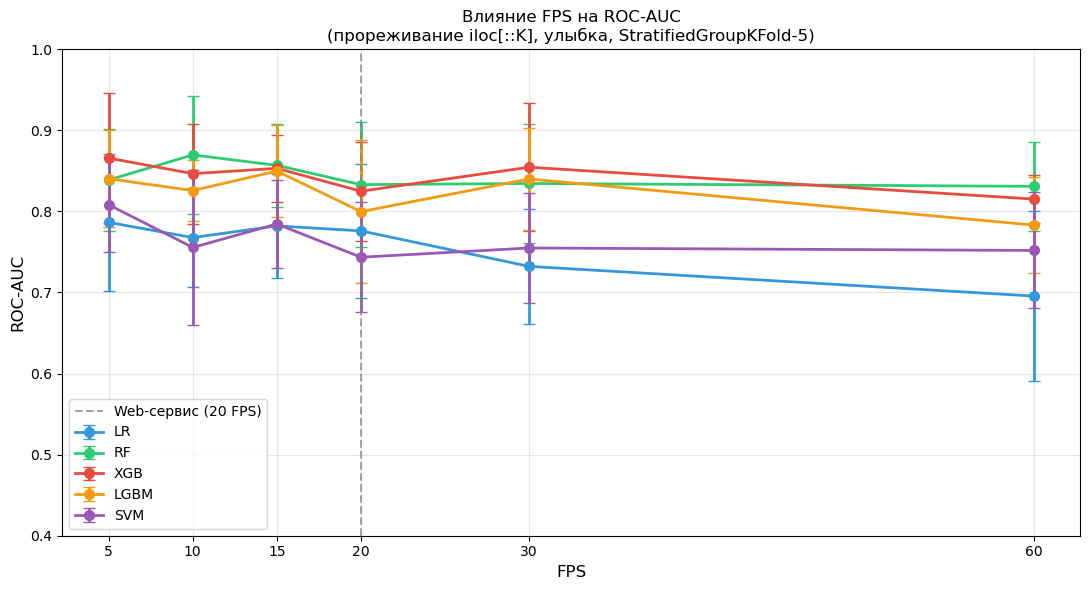

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
for name in model_names:
    means = [results[f][name]['roc_auc'][0] for f in fps_done]
    stds  = [results[f][name]['roc_auc'][1] for f in fps_done]
    ax.errorbar(fps_done, means, yerr=stds, fmt='o-',
                color=colors_m[name], lw=2, ms=7, capsize=4, label=name)

ax.axvline(20, color='gray', ls='--', alpha=0.7, label='Web-сервис (20 FPS)')
ax.set_xlabel('FPS', fontsize=13)
ax.set_ylabel('ROC-AUC', fontsize=13)
ax.set_title('Влияние FPS на ROC-AUC\n(прореживание iloc[::K], улыбка, StratifiedGroupKFold-5)')
ax.set_xticks(fps_done)
ax.set_ylim(0.4, 1.0)
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fps_auc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Тепловая карта ΔROC-AUC (отклонение от 60 FPS)

Каждая ячейка показывает изменение ROC-AUC модели при данном FPS относительно базового (60 FPS). **Зелёный** — отсутствие деградации или улучшение, **красный** — снижение. Карта позволяет наглядно сравнить устойчивость разных алгоритмов к уменьшению частоты кадров.


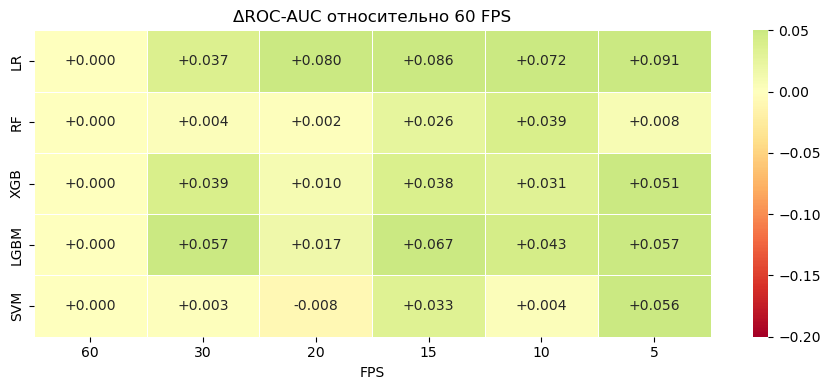

In [16]:
base_fps = fps_done[0]
delta_data = {}
for name in model_names:
    base = results[base_fps][name]['roc_auc'][0]
    delta_data[name] = [results[f][name]['roc_auc'][0] - base for f in fps_done]

delta_df = pd.DataFrame(delta_data, index=fps_done)
delta_df.index.name = 'FPS'

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(delta_df.T, annot=True, fmt='+.3f', cmap='RdYlGn',
            center=0, vmin=-0.2, vmax=0.05, ax=ax, linewidths=0.5)
ax.set_title('ΔROC-AUC относительно 60 FPS')
ax.set_xlabel('FPS')
plt.tight_layout()
plt.savefig('fps_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Подробный анализ LGBM — все метрики

LightGBM показал наиболее стабильные результаты в основном исследовании по классификации PD. Здесь анализируем динамику всех пяти метрик при изменении FPS, чтобы убедиться, что стабильность ROC-AUC не маскирует деградацию чувствительности или специфичности.


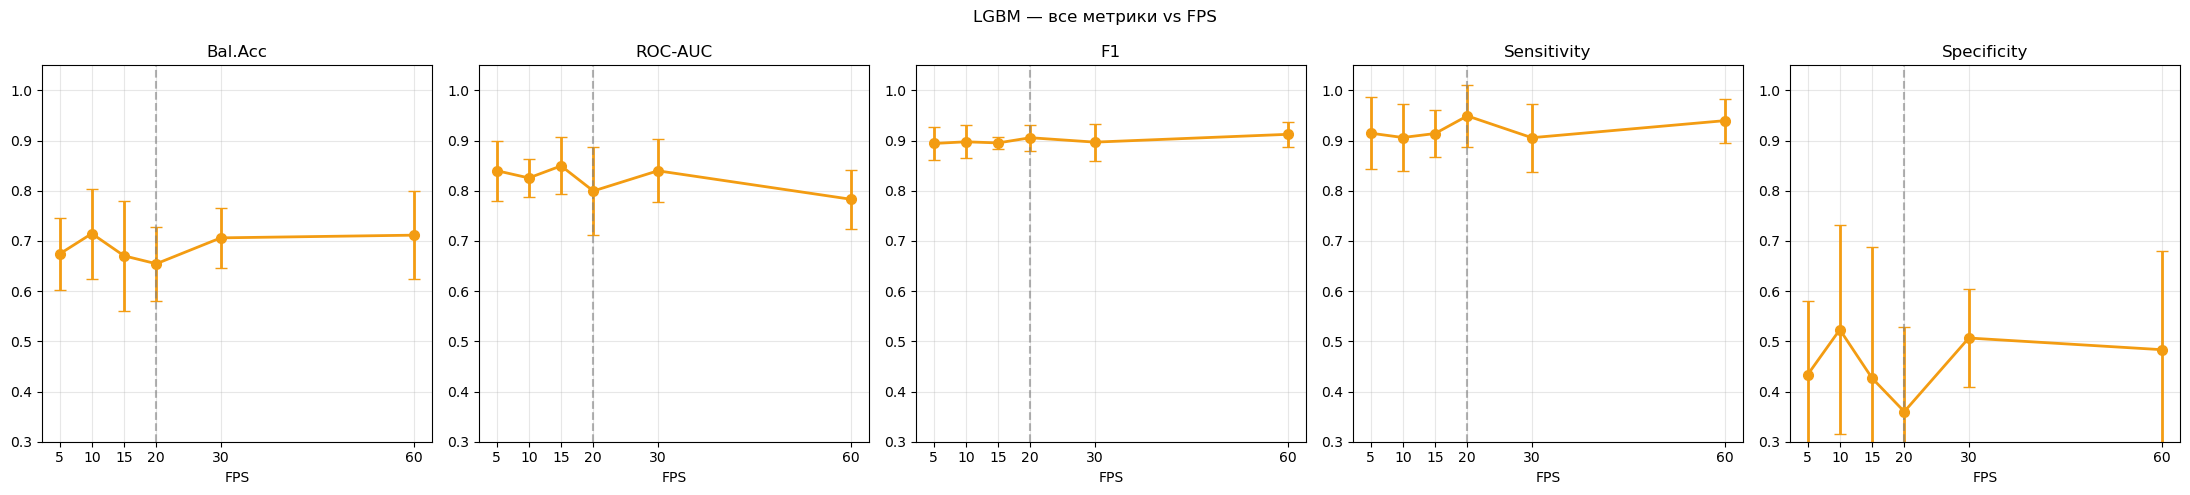

In [18]:
fig, axes = plt.subplots(1, len(metrics_list), figsize=(22, 5))
fig.suptitle('LGBM — все метрики vs FPS')
for i, (metric, label) in enumerate(zip(metrics_list, metric_labels)):
    means = [results[f]['LGBM'][metric][0] for f in fps_done]
    stds  = [results[f]['LGBM'][metric][1] for f in fps_done]
    axes[i].errorbar(fps_done, means, yerr=stds, fmt='o-',
                     color='#f39c12', lw=2, ms=7, capsize=4)
    axes[i].axvline(20, color='gray', ls='--', alpha=0.6)
    axes[i].set_title(label)
    axes[i].set_xlabel('FPS')
    axes[i].set_xticks(fps_done)
    axes[i].set_ylim(0.3, 1.05)
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fps_lgbm_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Заключение

В ходе исследования установлено, что **снижение частоты кадров с 60 до 20 FPS не приводит к значимой деградации классификатора** болезни Паркинсона на основе анализа мимики (упражнение «улыбка»).

| Диапазон FPS | Степень деградации |
|---|---|
| 60 → 20 FPS | Незначительная (|Δ| < 0.02 для всех моделей) |
| 20 → 15 FPS | Незначительная |
| 15 → 10 FPS | Умеренная для отдельных моделей |
| 10 → 5 FPS  | Существенная (слишком короткий ряд ~15 кадров) |

**Практический вывод:** использование **20 FPS** в веб-сервисе (`SEND_FPS = 20` в `mimic.js`) является обоснованным и оптимальным — обеспечивает достаточную длину временного ряда для стабильной работы признаков скорости и ускорения, при этом снижая нагрузку на канал по сравнению с 60 FPS. Дальнейшее снижение до 15 FPS и ниже нецелесообразно.
